# Facial Keypoints Detection — post-training diagnostics across all models

Every number below is computed on the same held-out 12% (`train_test_split(test_size=0.12, random_state=42)`), from
saved checkpoints; nothing is retrained. **v1** (direct regression) appears through its recorded per-keypoint table;
**v3** (100% data) has no honest held-out number because its monitor rows were in its training set, so it appears only
through Kaggle. The **seed band** |v2 − control| (same configuration, seeds 42 and 7) is shaded on every comparison:
a difference inside it is not evidence of an improvement.

In [1]:
import json, os, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt, seaborn as sns
import fkd_v4_common as C
import fkd_v4_configs as B
sns.set_theme(style="whitegrid")
dev = C.device()
data = C.load_data("data")
xva, yva, mva = C.to_gpu(data["imgs"][data["idx_va"]], data["y"][data["idx_va"]], dev)
print(dev, "| held-out rows", len(xva))

cuda | held-out rows 846


In [2]:
def load_v2():
    sd = torch.load("checkpoint_integral_continued.pt", map_location="cpu")["model_state"]
    mapped = {}
    for k, v in sd.items():
        if k.startswith("backbone."):
            mapped["backbone.net." + k[len("backbone."):]] = v
        elif k.startswith("head.deconv."):
            mapped["head.up." + k[len("head.deconv."):]] = v
        elif k.startswith("head.hm_conv."):
            mapped["head.hm." + k[len("head.hm_conv."):]] = v
    m = C.SingleStageModel(24, 1, beta=1.0, learn_beta=False, mapping="v2")
    missing, unexpected = m.load_state_dict(mapped, strict=False)
    assert set(missing) <= {"head.log_beta", "head.cells"} and not unexpected, (missing, unexpected)
    return m.to(dev).eval(), {"sigma": 1.0, "mapping": "v2"}

def load_run(run):
    spec = B.RUNS[run]
    m = eval(spec["model"], {"C": C})
    m.load_state_dict(torch.load(f"checkpoints/{run}.pt", map_location="cpu")["model_state"])
    return m.to(dev).eval(), spec["cfg"]

MODELS = {"v2": load_v2()}
RUNS = [r for r in ("v4ctrl", "v4a", "v4b", "v4c") if os.path.exists(f"checkpoints/{r}.pt")]
for run in RUNS:
    MODELS[run] = load_run(run)
print("runs with checkpoints:", RUNS)
v2_check = C.rmse(C.predict(MODELS["v2"][0], xva, mapping="v2"), yva, mva)
print(f"v2 reloaded through the shared classes: {v2_check:.4f}px (recorded 2.4385px)")
assert abs(v2_check - 2.4385) < 1e-3

runs with checkpoints: ['v4ctrl', 'v4a', 'v4b']


v2 reloaded through the shared classes: 2.4385px (recorded 2.4385px)


## 1. Held-out RMSE by model, decoder and flip test

In [3]:
rows, preds = [], {}
for name, (m, cfg) in MODELS.items():
    mp = cfg.get("mapping", "centered")
    r = {"model": name}
    for dec in ("softargmax", "argmax_shift", "dark"):
        for tta in (False, True):
            p = C.predict(m, xva, tta=tta, decoder=dec, sigma=cfg["sigma"], mapping=mp)
            r[f"{dec}{'+flip' if tta else ''}"] = C.rmse(p, yva, mva)
    preds[name] = C.predict(m, xva, mapping=mp)
    rows.append(r)
table = pd.DataFrame(rows).set_index("model").round(4)
band = abs(table.loc["v2", "softargmax"] - table.loc["v4ctrl", "softargmax"])
print(f"seed band |v2 - control| = {band:.4f} px")
table

seed band |v2 - control| = 0.0216 px


,softargmax,softargmax+flip,argmax_shift,argmax_shift+flip,dark,dark+flip
model,,,,,,
v2,2.4385,2.3724,12.6288,10.6805,17.6870,16.7425
v4ctrl,2.4601,2.3868,12.0772,10.3107,17.2107,15.1778
v4a,2.3055,2.1980,2.9306,2.5705,2.5720,2.3826
v4b,1.7985,1.7406,2.0472,1.9025,1.9365,1.8240


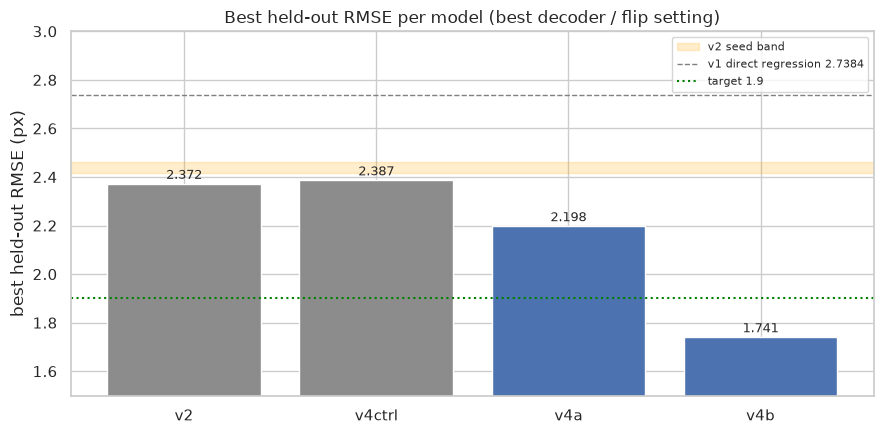

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
best = table.min(axis=1)
colors = ["#8c8c8c" if n in ("v2", "v4ctrl") else "#4C72B0" for n in best.index]
ax.bar(best.index, best.values, color=colors)
ax.axhspan(table.loc["v2", "softargmax"] - band, table.loc["v2", "softargmax"] + band, color="orange", alpha=0.2, label="v2 seed band")
ax.axhline(2.7384, ls="--", color="gray", lw=1, label="v1 direct regression 2.7384")
ax.axhline(1.9, ls=":", color="green", lw=1.5, label="target 1.9")
for i, v in enumerate(best.values):
    ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("best held-out RMSE (px)"); ax.set_ylim(1.5, 3.0); ax.legend(fontsize=8)
ax.set_title("Best held-out RMSE per model (best decoder / flip setting)")
plt.tight_layout(); plt.show()

## 2. Per-keypoint RMSE (v1 from its recorded table)

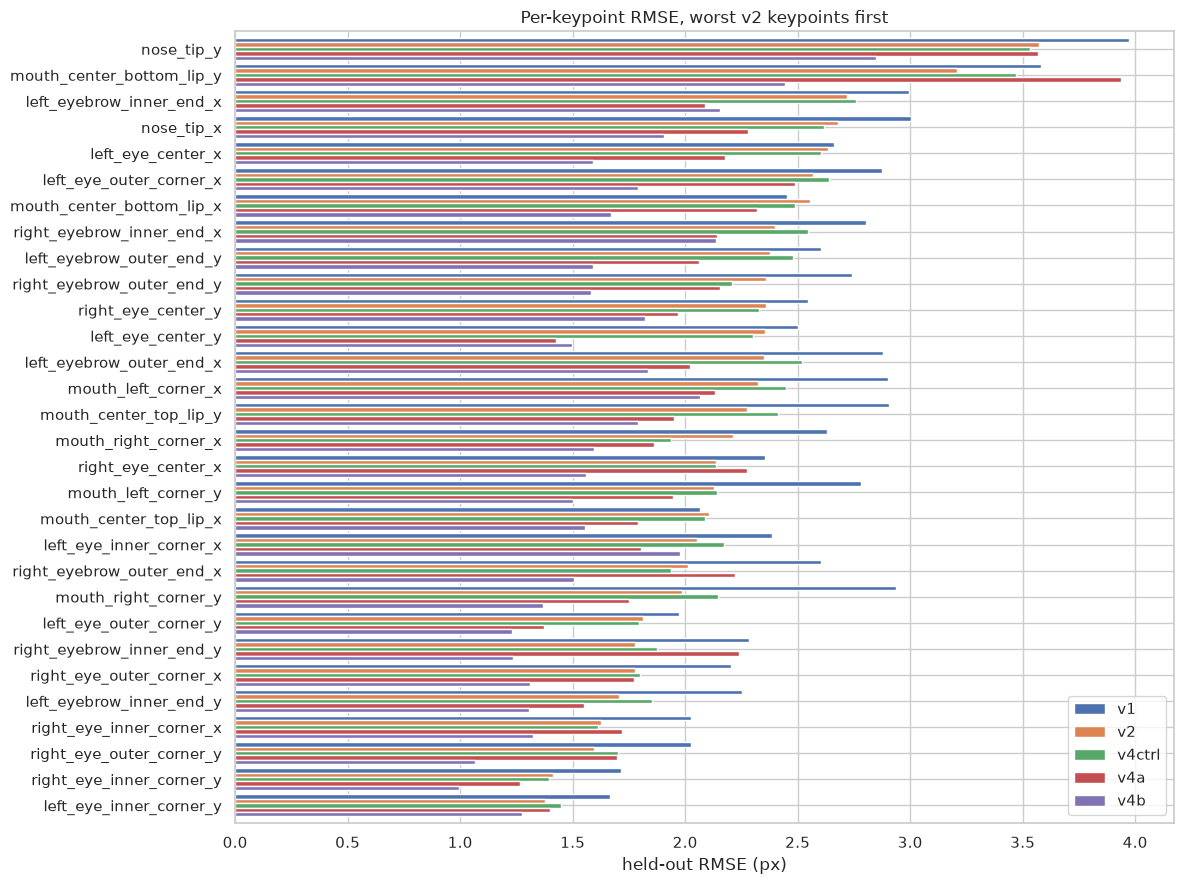

largest per-keypoint gains of v4b over v2:
 left_eye_center_x            1.046
mouth_center_bottom_lip_x    0.886
left_eye_center_y            0.859
left_eyebrow_outer_end_y     0.790
right_eyebrow_outer_end_y    0.778
left_eye_outer_corner_x      0.777
dtype: float32


In [5]:
LEGACY_PER_KP = {"nose_tip_y": 3.973695, "mouth_center_bottom_lip_y": 3.582114, "nose_tip_x": 3.003909,
 "left_eyebrow_inner_end_x": 2.992663, "mouth_right_corner_y": 2.935672, "mouth_center_top_lip_y": 2.906354,
 "mouth_left_corner_x": 2.900299, "left_eyebrow_outer_end_x": 2.880976, "left_eye_outer_corner_x": 2.876521,
 "right_eyebrow_inner_end_x": 2.803550, "mouth_left_corner_y": 2.780901, "right_eyebrow_outer_end_y": 2.739962,
 "left_eye_center_x": 2.659593, "mouth_right_corner_x": 2.629298, "left_eyebrow_outer_end_y": 2.604473,
 "right_eyebrow_outer_end_x": 2.601803, "right_eye_center_y": 2.545376, "left_eye_center_y": 2.500452,
 "mouth_center_bottom_lip_x": 2.451083, "left_eye_inner_corner_x": 2.384702, "right_eye_center_x": 2.355968,
 "right_eyebrow_inner_end_y": 2.281603, "left_eyebrow_inner_end_y": 2.253749, "right_eye_outer_corner_x": 2.205382,
 "mouth_center_top_lip_x": 2.065510, "right_eye_inner_corner_x": 2.024989, "right_eye_outer_corner_y": 2.024681,
 "left_eye_outer_corner_y": 1.972818, "right_eye_inner_corner_y": 1.715267, "left_eye_inner_corner_y": 1.665604}
pk = pd.DataFrame({n: C.per_keypoint_rmse(p, yva, mva) for n, p in preds.items()}, index=C.KEYPOINT_COLS)
pk.insert(0, "v1", pd.Series(LEGACY_PER_KP))
pk = pk.sort_values("v2", ascending=False)
fig, ax = plt.subplots(figsize=(12, 9))
pk.plot(kind="barh", ax=ax, width=0.85)
ax.invert_yaxis(); ax.set_xlabel("held-out RMSE (px)"); ax.set_title("Per-keypoint RMSE, worst v2 keypoints first")
plt.tight_layout(); plt.show()
best_v4 = min([r for r in ("v4a", "v4b", "v4c") if r in table.index], key=lambda n: table.loc[n].min())
gain = (pk["v2"] - pk[best_v4]).sort_values(ascending=False)
print(f"largest per-keypoint gains of {best_v4} over v2:\n", gain.head(6).round(3))

## 3. Centre-pull: slope of prediction on truth per coordinate (1 = unbiased)

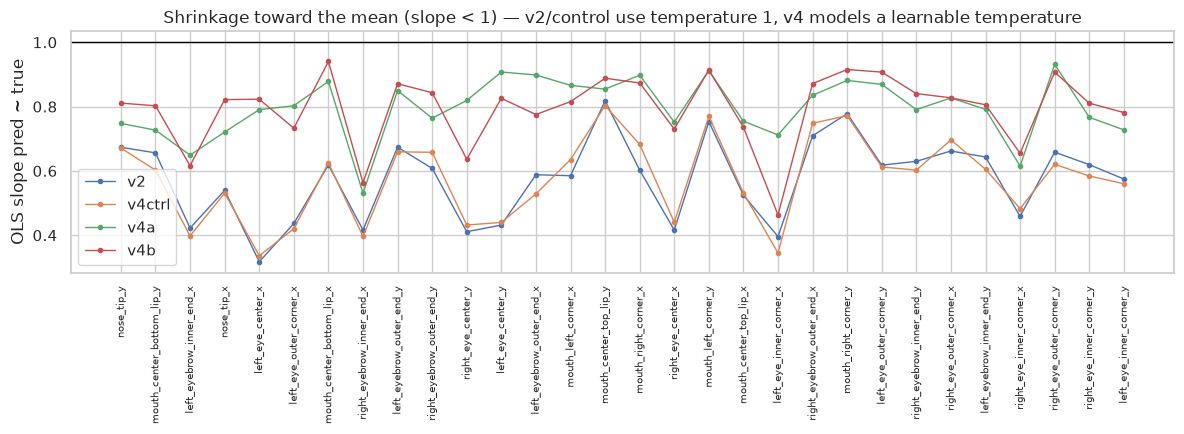

v2        0.5747
v4ctrl    0.5730
v4a       0.7957
v4b       0.7935
dtype: float64


In [6]:
slopes = pd.DataFrame({n: C.shrinkage_slopes(p, yva, mva) for n, p in preds.items()}, index=C.KEYPOINT_COLS)
fig, ax = plt.subplots(figsize=(12, 4.5))
slopes.loc[pk.index].plot(ax=ax, marker="o", ms=3, lw=1)
ax.axhline(1.0, color="black", lw=1); ax.set_ylabel("OLS slope pred ~ true")
ax.set_xticks(range(30)); ax.set_xticklabels(pk.index, rotation=90, fontsize=7)
ax.set_title("Shrinkage toward the mean (slope < 1) — v2/control use temperature 1, v4 models a learnable temperature")
plt.tight_layout(); plt.show()
print(slopes.mean().round(4))

## 4. Decoder ablation on v4b's 48x48 heatmaps (DARK vs argmax + quarter shift vs soft-argmax)

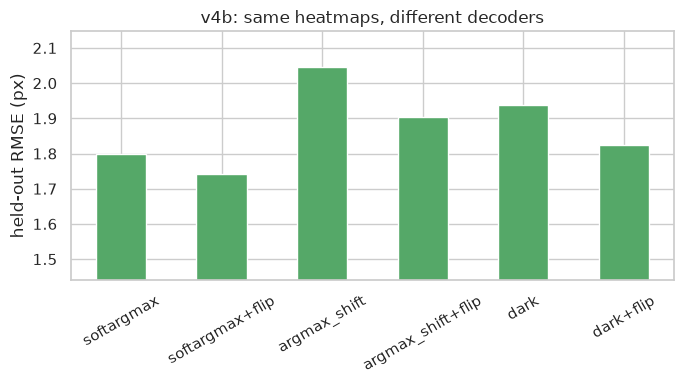

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
table.loc["v4b"].plot(kind="bar", ax=ax, color="#55A868")
ax.set_ylabel("held-out RMSE (px)"); ax.set_ylim(table.loc["v4b"].min() - 0.3, table.loc["v4b"].max() + 0.1)
ax.set_title("v4b: same heatmaps, different decoders"); plt.xticks(rotation=30); plt.tight_layout(); plt.show()

## 5. Procrustes split: rigid (pose/scale) vs non-rigid (shape) error on complete-case rows

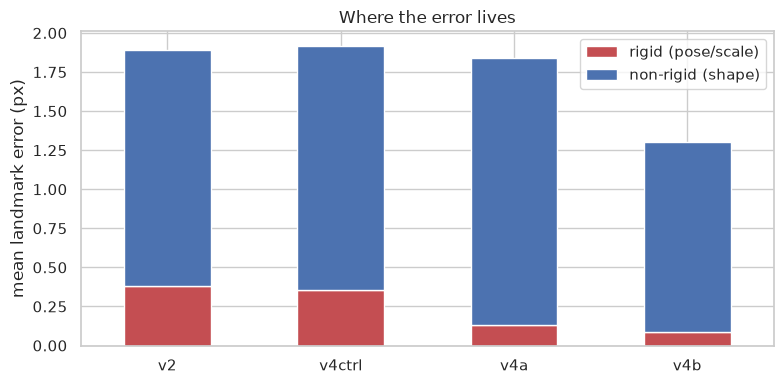

,rigid (pose/scale),non-rigid (shape)
v2,0.379,1.513
v4ctrl,0.356,1.559
v4a,0.132,1.709
v4b,0.086,1.213


In [8]:
def procrustes_split(pred):
    P, T, M = pred.cpu().numpy(), yva.cpu().numpy(), mva.cpu().numpy().astype(bool)
    rig, non = [], []
    for i in np.where(M.all(1))[0]:
        t, p = T[i].reshape(15, 2), P[i].reshape(15, 2)
        tot = np.sqrt(((p - t) ** 2).sum(1)).mean()
        mt, mp = t.mean(0), p.mean(0); t0, p0 = t - mt, p - mp
        st, sp = np.linalg.norm(t0), np.linalg.norm(p0)
        U, _, Vt = np.linalg.svd((p0 / sp).T @ (t0 / st))
        al = (p0 / sp) @ (U @ Vt) * st + mt
        n = np.sqrt(((al - t) ** 2).sum(1)).mean(); non.append(n); rig.append(max(tot - n, 0))
    return np.mean(rig), np.mean(non)
proc = pd.DataFrame({n: procrustes_split(p) for n, p in preds.items()}, index=["rigid (pose/scale)", "non-rigid (shape)"]).T
proc.plot(kind="bar", stacked=True, figsize=(8, 4), color=["#C44E52", "#4C72B0"])
plt.ylabel("mean landmark error (px)"); plt.title("Where the error lives"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()
proc.round(3)

## 6. Robustness: Gaussian pixel noise and horizontal shift

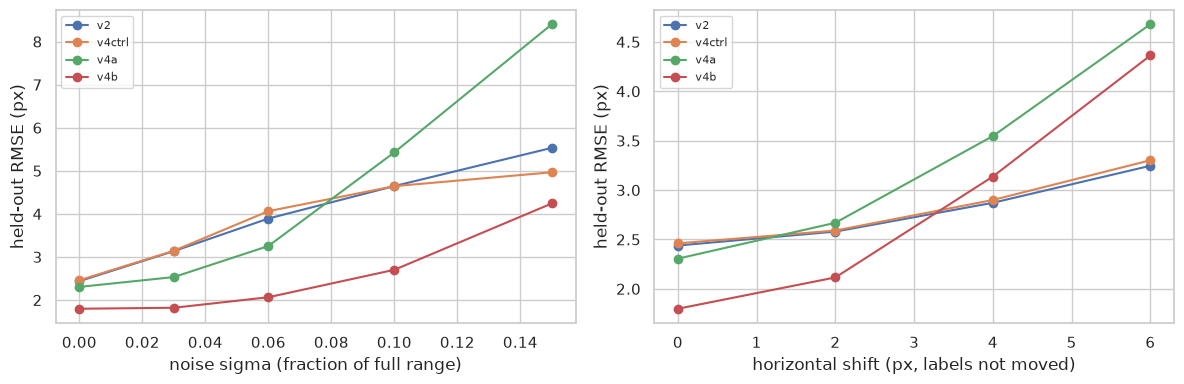

In [9]:
def perturbed_rmse(name, fn):
    m, cfg = MODELS[name]
    return C.rmse(C.predict(m, fn(xva), mapping=cfg.get("mapping", "centered")), yva, mva)
noise = [0, 0.03, 0.06, 0.1, 0.15]
shifts = [0, 2, 4, 6]
g = torch.Generator(device=xva.device).manual_seed(0)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for name in MODELS:
    ax[0].plot(noise, [perturbed_rmse(name, lambda x, s=s: (x + s * torch.randn(x.shape, generator=g, device=x.device)).clamp(0, 1)) for s in noise], marker="o", label=name)
    ax[1].plot(shifts, [perturbed_rmse(name, lambda x, s=s: torch.roll(x, s, dims=3)) for s in shifts], marker="o", label=name)
ax[0].set_xlabel("noise sigma (fraction of full range)"); ax[1].set_xlabel("horizontal shift (px, labels not moved)")
for a in ax: a.set_ylabel("held-out RMSE (px)"); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. In-training statistics, drawn after the fact

No figure was drawn while training; every epoch wrote its statistics to `results/<run>_history.json`. These panels read
those files: held-out RMSE (dots = flip test, every 10 epochs), the loss split into its L1 and heatmap parts, learning rate,
learned softmax temperature, gradient norm, centre-pull slope, and softmax entropy / peak probability.

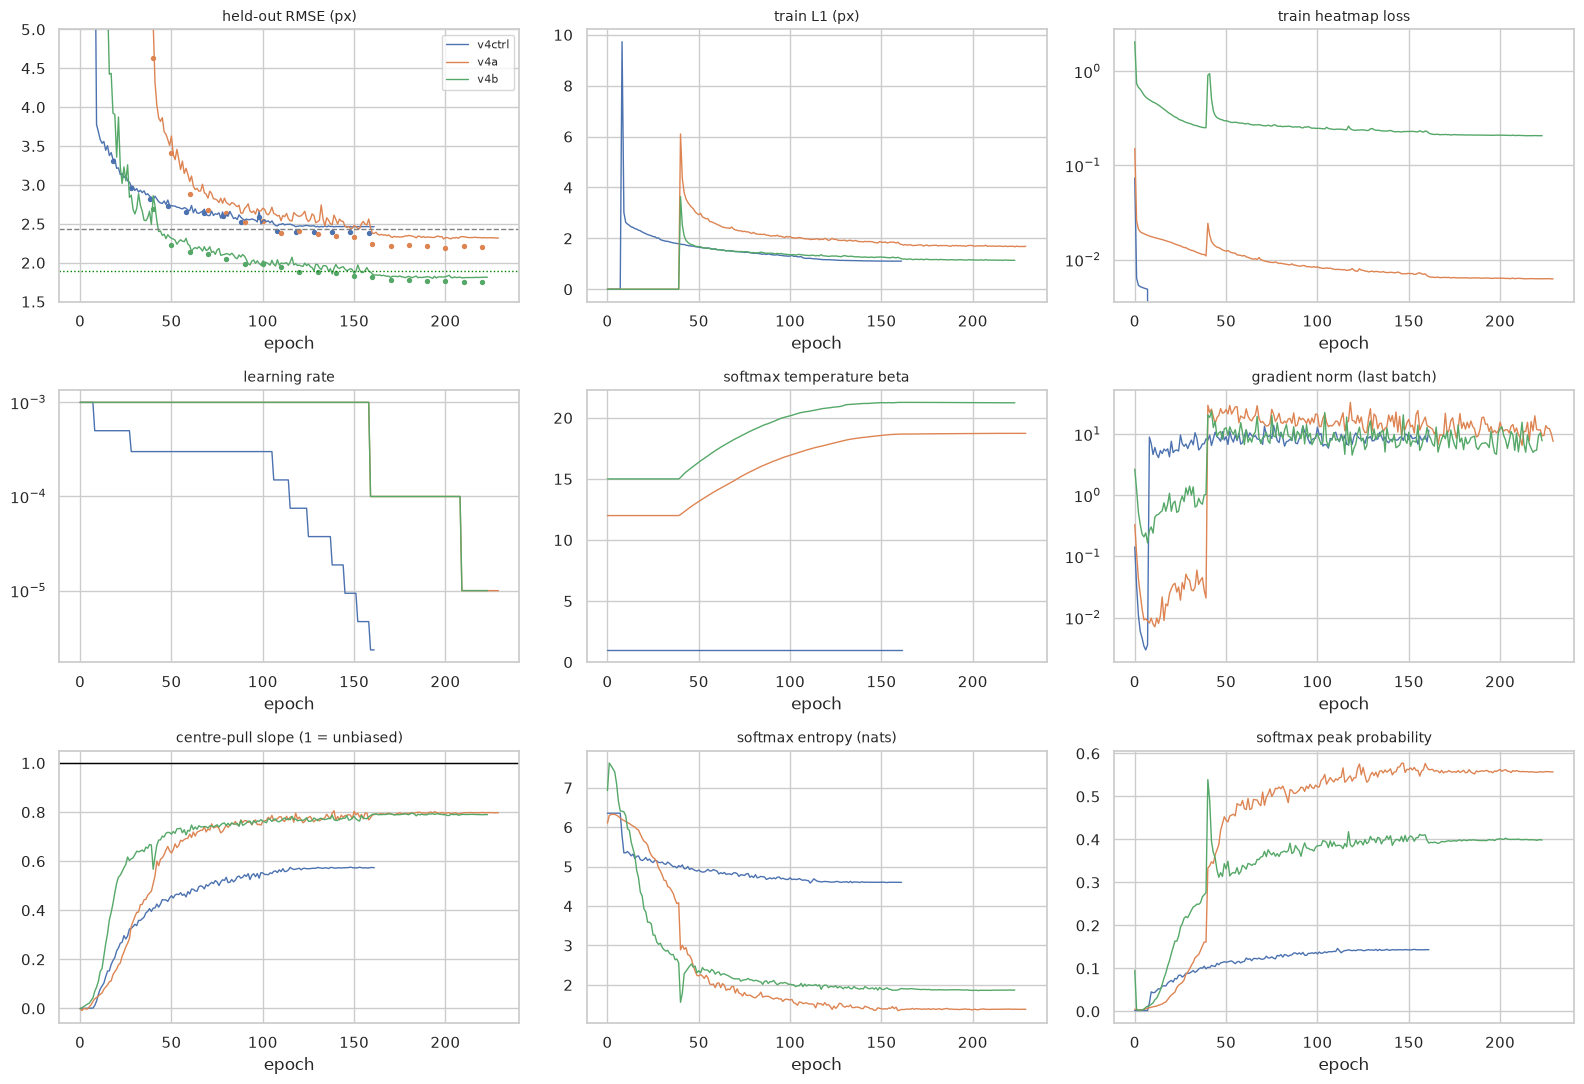

In [10]:
H = {run: json.load(open(f"results/{run}_history.json")) for run in RUNS}
panels = [("val_rmse", "held-out RMSE (px)"), ("train_l1", "train L1 (px)"), ("train_hm", "train heatmap loss"),
          ("lr", "learning rate"), ("beta", "softmax temperature beta"), ("grad_norm", "gradient norm (last batch)"),
          ("val_slope_mean", "centre-pull slope (1 = unbiased)"), ("val_entropy", "softmax entropy (nats)"),
          ("val_maxprob", "softmax peak probability")]
fig, axes = plt.subplots(3, 3, figsize=(16, 11)); axes = axes.ravel()
for (key, label), ax in zip(panels, axes):
    for run, h in H.items():
        ys = [np.nan if v is None else v for v in h[key]]
        ax.plot(h["epoch"], ys, lw=1, label=run)
        if key == "val_rmse":
            tt = [(e, v) for e, v in zip(h["epoch"], h["val_rmse_tta"]) if v is not None]
            if tt: ax.scatter(*zip(*tt), s=8)
    if key == "val_rmse":
        ax.axhline(2.4385, ls="--", color="gray", lw=1); ax.axhline(1.9, ls=":", color="green", lw=1); ax.set_ylim(1.5, 5)
    if key in ("lr", "train_hm", "grad_norm"): ax.set_yscale("log")
    if key == "val_slope_mean": ax.axhline(1.0, color="black", lw=1)
    ax.set_title(label, fontsize=10); ax.set_xlabel("epoch")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

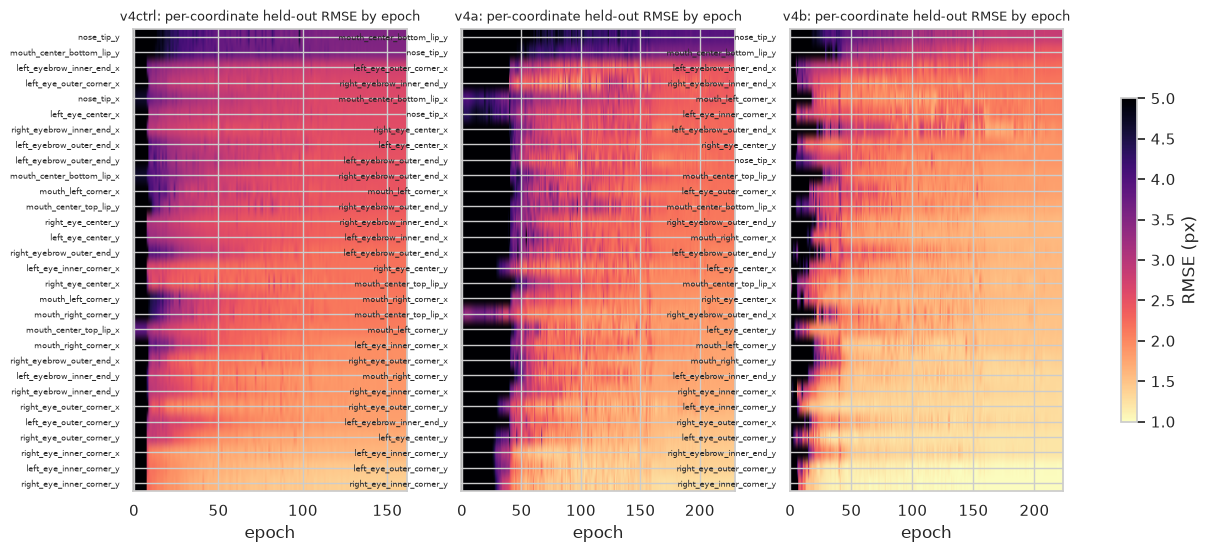

In [11]:
fig, axes = plt.subplots(1, len(H), figsize=(5 * len(H), 6))
for ax, (run, h) in zip(axes, H.items()):
    M = np.array(h["val_per_kp"]).T
    order = np.argsort(-M[:, -1])
    im = ax.imshow(M[order], aspect="auto", cmap="magma_r", vmin=1, vmax=5)
    ax.set_title(f"{run}: per-coordinate held-out RMSE by epoch", fontsize=9); ax.set_xlabel("epoch")
    ax.set_yticks(range(30)); ax.set_yticklabels(np.array(h["keypoints"])[order], fontsize=6)
fig.colorbar(im, ax=axes, shrink=0.7, label="RMSE (px)"); plt.show()

## 8. Best and worst held-out faces for the best v4 model

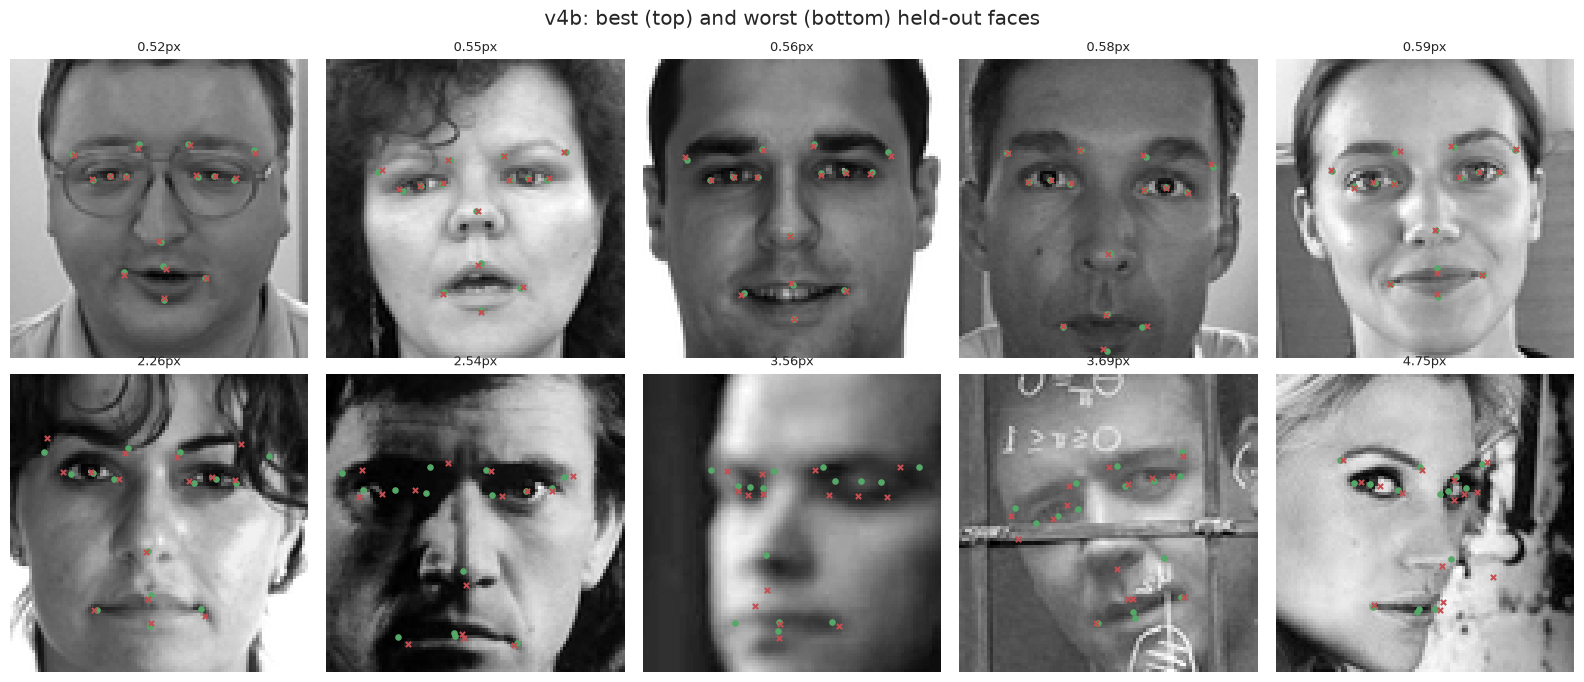

In [12]:
p = preds[best_v4].cpu().numpy(); t = yva.cpu().numpy(); mm = mva.cpu().numpy().astype(bool)
full = np.where(mm.all(1))[0]
err = np.sqrt(((p[full] - t[full]) ** 2).mean(1)); order = full[np.argsort(err)]
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for r, idxs in enumerate((order[:5], order[-5:])):
    for c, i in enumerate(idxs):
        a = axes[r, c]; a.imshow(xva[i, 0].cpu(), cmap="gray")
        a.scatter(t[i, 0::2], t[i, 1::2], c="#55A868", s=14); a.scatter(p[i, 0::2], p[i, 1::2], c="#C44E52", s=14, marker="x")
        a.set_title(f"{np.sqrt(((p[i]-t[i])**2).mean()):.2f}px", fontsize=9); a.axis("off")
axes[0, 0].set_ylabel("best"); axes[1, 0].set_ylabel("worst")
plt.suptitle(f"{best_v4}: best (top) and worst (bottom) held-out faces"); plt.tight_layout(); plt.show()

In [13]:
summary = {"table": table.to_dict(), "seed_band": float(band), "best_v4": best_v4,
           "per_keypoint": pk.to_dict(), "slope_mean": slopes.mean().to_dict(), "procrustes": proc.to_dict(),
           "v2_reloaded_rmse": v2_check}
json.dump(summary, open("results/posttraining_summary.json", "w"), indent=2, default=float)
print(json.dumps({k: summary[k] for k in ("seed_band", "best_v4", "slope_mean")}, indent=2, default=float))

{
  "seed_band": 0.021600000000000286,
  "best_v4": "v4b",
  "slope_mean": {
    "v2": 0.5746888061113423,
    "v4ctrl": 0.5730086569821019,
    "v4a": 0.7957021881210432,
    "v4b": 0.7935402492516604
  }
}
